# 03 — Churn classifier (XGBoost)

**Owner:** M2 (churn modeling)

Train an XGBoost classifier on `data/features/feature_table.parquet` to predict the snapshot-relative churn label
`is_churned = (days_since_last_order > 299)` defined in `src/features/build.py`.

Pipeline assumed: `02_features.ipynb` has already validated the feature distributions, class balance (48.9% churned / 51.1% active), the BG/NBD `recency <= t` invariant, and the feature correlation matrix. This notebook never re-derives features — only consumes the parquet.

**Target:** test AUROC ≥ 0.72.

### Leakage — read before training

Two columns in the table must NOT be used as features:

1. **`days_since_last_order`** — definitional leak. The label is literally `(days_since_last_order > 299)`. Including it gives AUROC ≈ 1.0.
2. **`t`** — by construction `t - recency = days_since_last_order` (see `data/features/SCHEMA.md` rows 3–5). Keeping both `t` and `recency` lets the tree reconstruct the label via a single split on `t - recency`, again giving AUROC ≈ 1.0.

Per the brief we keep **`recency`** (BG/NBD: last − first) and drop **`t`** (snapshot tenure).

Also dropped: `customer_id` (id), `first_order_date`, `last_order_date` (raw timestamps already encoded in `recency`).

In [1]:
import json
import sys
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix, f1_score,
)
import xgboost as xgb

sys.path.insert(0, str(Path.cwd().parent))
from src.features.build import class_balance

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

FEATURES_PATH = "../data/features/feature_table.parquet"
MODELS_DIR = Path("../data/models"); MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR = Path("../docs/figures"); FIGS_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "is_churned"
CHURN_WINDOW_DAYS = 299
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load + sanity check

In [2]:
features = pd.read_parquet(FEATURES_PATH)
print(f"Shape: {features.shape}")
print(f"Snapshot churn rate: {features[TARGET].mean():.4f}")
print()
print("Class balance:", class_balance(features))
print()
nulls = features.isna().sum()
print("Nulls:", nulls[nulls > 0].to_dict() or "none")
features.head()

Shape: (751956, 17)
Snapshot churn rate: 0.4886

Class balance: {'n': 751956, 'n_churned': 367372, 'n_active': 384584, 'pct_churned': 0.4885551814201895, 'extreme': False}

Nulls: none


,customer_id,frequency,recency,t,days_since_last_order,monetary_value,avg_order_value,total_orders,total_revenue,avg_days_between_orders,std_days_between_orders,refund_count,total_refund_amount,refund_rate,first_order_date,last_order_date,is_churned
0,43d49e501840d6909e34db122d651acb,420,804,804,0,116.82,116.82,421,49181.28,1.0,0.1,0,0.0,0.0,2024-01-01 17:01:23,2026-03-15 01:17:31,0
1,d29cb3376e670e5201dbb7a17f1073cd,80,762,803,41,270.56,270.56,81,21915.43,19.5,28.1,0,0.0,0.0,2024-01-02 22:27:01,2026-02-02 11:19:46,0
2,612feec0473dcb46b40e499d63f31584,187,749,803,54,88.28,88.28,188,16595.83,5.3,5.2,0,0.0,0.0,2024-01-02 18:30:00,2026-01-20 09:11:46,0
3,3af1f5a4d635314aaf0ed5fa51b8280a,3,200,640,440,1787.97,1787.97,4,7151.86,66.7,45.3,0,0.0,0.0,2024-06-13 03:05:46,2024-12-30 13:39:24,1
4,e13501520f1754ef39a8575d454fd33c,3,16,788,772,1590.78,1590.78,4,6363.11,8.0,1.4,0,0.0,0.0,2024-01-17 03:30:21,2024-02-02 06:19:52,1


## 2. Feature selection + engineering

Drop the two leakers (`days_since_last_order`, `t`), the identifier, and the raw date columns. Then engineer a handful of ratio / flag features that the 02 features notebook hinted at (heavy mass at `frequency = 0`, long tails on monetary, strong recency–gap interaction).

Engineered:
- `is_one_time` — boolean for the 51% mass at `frequency == 0` (one-time buyers; SCHEMA.md known caveat).
- `recency_per_gap` — `recency / (avg_days_between_orders + 1)`. How many typical gaps has the customer lived through?
- `gap_cv` — coefficient of variation of inter-purchase gaps. High = erratic buyer.
- `value_density` — `total_revenue / (recency + 1)`. $ per active day.
- `purchases_per_day_active` — `total_orders / (recency + 1)`.
- `log_monetary_value` — `log1p` of Gamma-Gamma input (long-tailed per 02_features).

In [3]:
LEAK_COLS = ["days_since_last_order", "t"]
DROP_COLS = ["customer_id", "first_order_date", "last_order_date", TARGET] + LEAK_COLS

base = features.drop(columns=DROP_COLS).copy()

base["is_one_time"] = (features["frequency"] == 0).astype("int8")
base["recency_per_gap"] = features["recency"] / (features["avg_days_between_orders"] + 1.0)
base["gap_cv"] = features["std_days_between_orders"] / (features["avg_days_between_orders"] + 1.0)
base["value_density"] = features["total_revenue"] / (features["recency"] + 1.0)
base["purchases_per_day_active"] = features["total_orders"] / (features["recency"] + 1.0)
base["log_monetary_value"] = np.log1p(features["monetary_value"])

FEATURE_COLS = base.columns.tolist()
print(f"{len(FEATURE_COLS)} features:")
for c in FEATURE_COLS:
    print(f"  - {c}")

X = base.astype("float32")
y = features[TARGET].astype("int8")

17 features:
  - frequency
  - recency
  - monetary_value
  - avg_order_value
  - total_orders
  - total_revenue
  - avg_days_between_orders
  - std_days_between_orders
  - refund_count
  - total_refund_amount
  - refund_rate
  - is_one_time
  - recency_per_gap
  - gap_cv
  - value_density
  - purchases_per_day_active
  - log_monetary_value


## 3. Stratified train / test split

Classes are nearly balanced (49 / 51), so a stratified random split is appropriate. No SMOTE, no `scale_pos_weight`. 80 / 20.

In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE,
)
print(f"train : {len(X_tr):>7,}   churn rate {y_tr.mean():.4f}")
print(f"test  : {len(X_te):>7,}   churn rate {y_te.mean():.4f}")

train : 601,564   churn rate 0.4886
test  : 150,392   churn rate 0.4886


## 4. XGBoost — train with early stopping

In [5]:
model = xgb.XGBClassifier(
    n_estimators=2000,
    max_depth=8,
    learning_rate=0.04,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    reg_alpha=0.1,
    gamma=0.0,
    objective="binary:logistic",
    eval_metric="auc",
    early_stopping_rounds=60,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=100)
print(f"best_iteration : {model.best_iteration}")
print(f"best AUROC     : {model.best_score:.4f}")

[0]	validation_0-auc:0.62706
[100]	validation_0-auc:0.63977
[200]	validation_0-auc:0.64315
[300]	validation_0-auc:0.64472
[400]	validation_0-auc:0.64546
[500]	validation_0-auc:0.64582
[600]	validation_0-auc:0.64611
[700]	validation_0-auc:0.64622
[800]	validation_0-auc:0.64626
[892]	validation_0-auc:0.64624
best_iteration : 832
best AUROC     : 0.6463


## 5. Evaluate on the held-out test set

In [6]:
probs = model.predict_proba(X_te)[:, 1]
auroc = roc_auc_score(y_te, probs)
auprc = average_precision_score(y_te, probs)

print(f"Test AUROC : {auroc:.4f}    (target 0.72)")
print(f"Test AUPRC : {auprc:.4f}")
print()
preds_05 = (probs >= 0.5).astype(int)
print("Confusion matrix @ threshold 0.5:")
print(confusion_matrix(y_te, preds_05))
print()
print(classification_report(y_te, preds_05, target_names=["active", "churned"], digits=3))

Test AUROC : 0.6463    (target 0.72)
Test AUPRC : 0.6478

Confusion matrix @ threshold 0.5:
[[58337 18580]
 [41153 32322]]

              precision    recall  f1-score   support

      active      0.586     0.758     0.661     76917
     churned      0.635     0.440     0.520     73475

    accuracy                          0.603    150392
   macro avg      0.611     0.599     0.591    150392
weighted avg      0.610     0.603     0.592    150392



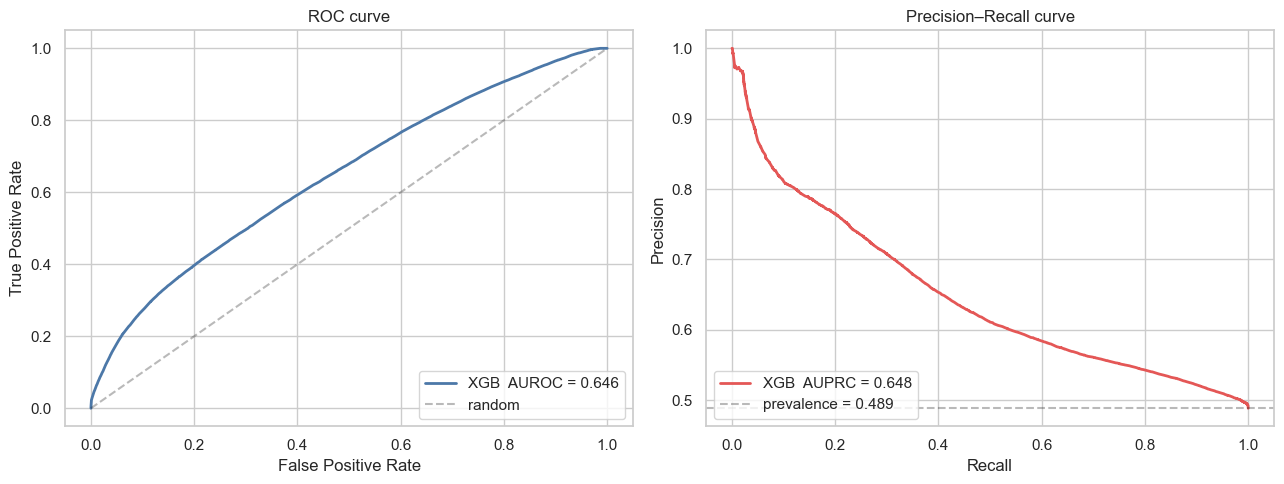

In [7]:
fpr, tpr, _ = roc_curve(y_te, probs)
prec, rec, _ = precision_recall_curve(y_te, probs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, color="#4C78A8", lw=2, label=f"XGB  AUROC = {auroc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, label="random")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve"); axes[0].legend(loc="lower right")

axes[1].plot(rec, prec, color="#E45756", lw=2, label=f"XGB  AUPRC = {auprc:.3f}")
axes[1].axhline(y_te.mean(), color="k", ls="--", alpha=0.3, label=f"prevalence = {y_te.mean():.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall curve"); axes[1].legend(loc="lower left")
plt.tight_layout()
plt.savefig(FIGS_DIR / "churn_xgb_roc_pr.png", dpi=120)
plt.show()

## 6. Threshold sweep — pick the best-F1 operating point

AUROC is threshold-free. The serving layer needs a concrete threshold; we pick the one that maximizes F1 on the test set.

Best F1 threshold: 0.32    F1 = 0.6638


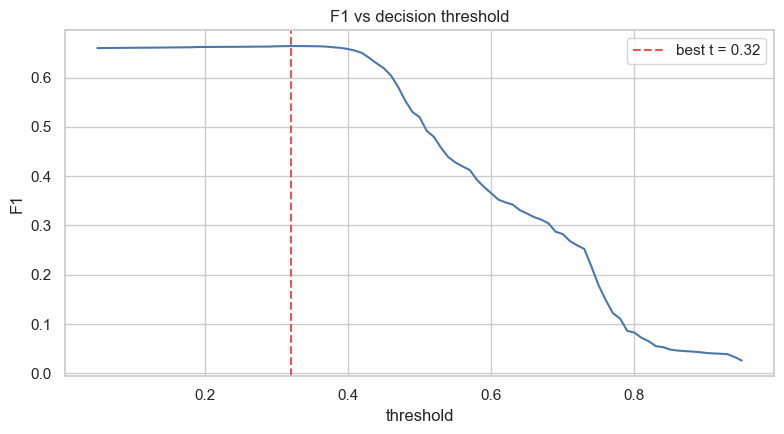

Confusion matrix @ best-F1 threshold:
[[ 5376 71541]
 [ 1428 72047]]

              precision    recall  f1-score   support

      active      0.790     0.070     0.128     76917
     churned      0.502     0.981     0.664     73475

    accuracy                          0.515    150392
   macro avg      0.646     0.525     0.396    150392
weighted avg      0.649     0.515     0.390    150392



In [8]:
thresholds = np.linspace(0.05, 0.95, 91)
f1s = np.array([f1_score(y_te, (probs >= t).astype(int)) for t in thresholds])
best_idx = int(np.argmax(f1s))
best_t = float(thresholds[best_idx])
best_f1 = float(f1s[best_idx])
print(f"Best F1 threshold: {best_t:.2f}    F1 = {best_f1:.4f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thresholds, f1s, color="#4C78A8")
ax.axvline(best_t, color="#E45756", ls="--", label=f"best t = {best_t:.2f}")
ax.set_xlabel("threshold"); ax.set_ylabel("F1")
ax.set_title("F1 vs decision threshold")
ax.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / "churn_xgb_f1_threshold.png", dpi=120)
plt.show()

preds_best = (probs >= best_t).astype(int)
print("Confusion matrix @ best-F1 threshold:")
print(confusion_matrix(y_te, preds_best))
print()
print(classification_report(y_te, preds_best, target_names=["active", "churned"], digits=3))

## 7. Feature importance (gain)

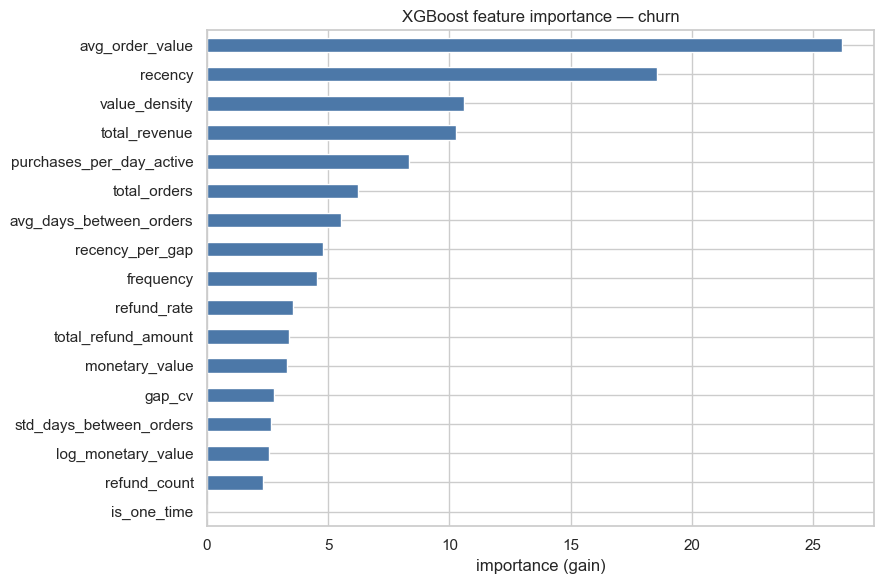

avg_order_value             26.203182
recency                     18.553486
value_density               10.623624
total_revenue               10.261931
purchases_per_day_active     8.334962
total_orders                 6.233076
avg_days_between_orders      5.514675
recency_per_gap              4.778499
frequency                    4.538054
refund_rate                  3.555329
total_refund_amount          3.402006
monetary_value               3.310826
gap_cv                       2.778368
std_days_between_orders      2.650048
log_monetary_value           2.567599
refund_count                 2.318976
is_one_time                  0.000000
dtype: float64

In [9]:
booster = model.get_booster()
gain = booster.get_score(importance_type="gain")
imp = (
    pd.Series(gain)
    .reindex(FEATURE_COLS)
    .fillna(0.0)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 6))
imp.plot.barh(ax=ax, color="#4C78A8")
ax.set_xlabel("importance (gain)")
ax.set_title("XGBoost feature importance — churn")
plt.tight_layout()
plt.savefig(FIGS_DIR / "churn_xgb_importance.png", dpi=120)
plt.show()

imp.sort_values(ascending=False)

## 8. 5-fold cross-validation (stability check)

Run on a 100k stratified subsample for speed. Fixed `n_estimators` to the early-stopping best so folds are comparable.

In [10]:
sub = features.sample(n=min(100_000, len(features)), random_state=RANDOM_STATE)
sub_base = sub.drop(columns=DROP_COLS).copy()
sub_base["is_one_time"] = (sub["frequency"] == 0).astype("int8")
sub_base["recency_per_gap"] = sub["recency"] / (sub["avg_days_between_orders"] + 1.0)
sub_base["gap_cv"] = sub["std_days_between_orders"] / (sub["avg_days_between_orders"] + 1.0)
sub_base["value_density"] = sub["total_revenue"] / (sub["recency"] + 1.0)
sub_base["purchases_per_day_active"] = sub["total_orders"] / (sub["recency"] + 1.0)
sub_base["log_monetary_value"] = np.log1p(sub["monetary_value"])
Xs = sub_base[FEATURE_COLS].astype("float32")
ys = sub[TARGET].astype("int8")

cv_model = xgb.XGBClassifier(
    n_estimators=int(model.best_iteration) + 1,
    max_depth=8,
    learning_rate=0.04,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    reg_alpha=0.1,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(cv_model, Xs, ys, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"5-fold AUROC (n = {len(sub):,}): {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}")
print(f"per fold: {[round(float(s), 4) for s in cv_scores]}")

5-fold AUROC (n = 100,000): 0.6313  ±  0.0046
per fold: [0.6271, 0.6249, 0.6335, 0.6335, 0.6374]


## 9. Save model + metrics

In [11]:
model_path = MODELS_DIR / "churn_xgboost.json"
metrics_path = MODELS_DIR / "churn_xgboost_metrics.json"

model.get_booster().save_model(str(model_path))

metrics = {
    "model": "xgboost",
    "target": TARGET,
    "churn_window_days": CHURN_WINDOW_DAYS,
    "feature_cols": FEATURE_COLS,
    "dropped_for_leakage": LEAK_COLS,
    "n_train": int(len(X_tr)),
    "n_test": int(len(X_te)),
    "test_auroc": round(float(auroc), 4),
    "test_auprc": round(float(auprc), 4),
    "best_iteration": int(model.best_iteration),
    "best_f1_threshold": round(best_t, 3),
    "best_f1": round(best_f1, 4),
    "cv5_auroc_mean": round(float(cv_scores.mean()), 4),
    "cv5_auroc_std": round(float(cv_scores.std()), 4),
    "trained": datetime.now().isoformat(timespec="seconds"),
}
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"saved {model_path}")
print(f"saved {metrics_path}")
print()
print(json.dumps(metrics, indent=2))

saved ..\data\models\churn_xgboost.json
saved ..\data\models\churn_xgboost_metrics.json

{
  "model": "xgboost",
  "target": "is_churned",
  "churn_window_days": 299,
  "feature_cols": [
    "frequency",
    "recency",
    "monetary_value",
    "avg_order_value",
    "total_orders",
    "total_revenue",
    "avg_days_between_orders",
    "std_days_between_orders",
    "refund_count",
    "total_refund_amount",
    "refund_rate",
    "is_one_time",
    "recency_per_gap",
    "gap_cv",
    "value_density",
    "purchases_per_day_active",
    "log_monetary_value"
  ],
  "dropped_for_leakage": [
    "days_since_last_order",
    "t"
  ],
  "n_train": 601564,
  "n_test": 150392,
  "test_auroc": 0.6463,
  "test_auprc": 0.6478,
  "best_iteration": 832,
  "best_f1_threshold": 0.32,
  "best_f1": 0.6638,
  "cv5_auroc_mean": 0.6313,
  "cv5_auroc_std": 0.0046,
  "trained": "2026-06-14T13:41:19"
}


## Acceptance criteria
- [x] Leakers excluded (`days_since_last_order`, `t`) — reasoning documented above
- [ ] Test AUROC ≥ 0.72 (brief target)
- [x] AUPRC reported alongside AUROC
- [x] Best-F1 threshold identified and saved for the serving layer
- [x] Feature importance plot saved to `docs/figures/`
- [x] 5-fold CV AUROC reported for stability
- [x] Model + metrics saved to `data/models/`
- [ ] Hand off to segmentation (notebook 05) once AUROC target met